# EDA: анамнезы и группы ограничений

Разведочный анализ перед обучением: распределение групп, дисбаланс, доминирующие коды, длины текстов, проверка утечек между сплитами.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data import load_split, load_xy, normalize
from src.mapping import GROUPS, description_of, group_of, is_dropped

REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

Matplotlib is building the font cache; this may take a moment.


In [2]:
rows = []
for split in ("train", "dev", "test"):
    for r in load_split(split):
        rows.append({
            "split": split,
            "code": r["code"],
            "group": group_of(r["code"]),
            "dropped": is_dropped(r["code"]),
            "text": r["symptoms"],
        })
df = pd.DataFrame(rows)
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].apply(lambda t: len(normalize(t).split()))
print("всего записей:", len(df))
print(df["split"].value_counts().to_dict())
df.head()

всего записей: 6360
{'train': 4690, 'dev': 848, 'test': 822}


,split,code,group,dropped,text,n_chars,n_words
0,train,M17,СУСТАВЫ,False,Жалобы на болит во всех суставах но более в кр...,184,30
1,train,M53,ПОЗВОНОЧНИК,False,На боли в правом плече с иррадиацией в локтево...,55,10
2,train,K29,ЖКТ/БРЮШНЫЕ,False,"боль в эпигастрии после погрешности в диете, в...",93,14
3,train,M54,ПОЗВОНОЧНИК,False,"боль в правом плечевом суставе, в правом плече...",220,34
4,train,E27,ЭНДОКРИН/МЕТАБОЛ,False,- приливы пота в только на улице - снижение ве...,138,25


## Распределение по группам и дисбаланс

DROP-коды (D50/H65/Z00) исключаются из обучения, поэтому смотрим на 8 рабочих групп.

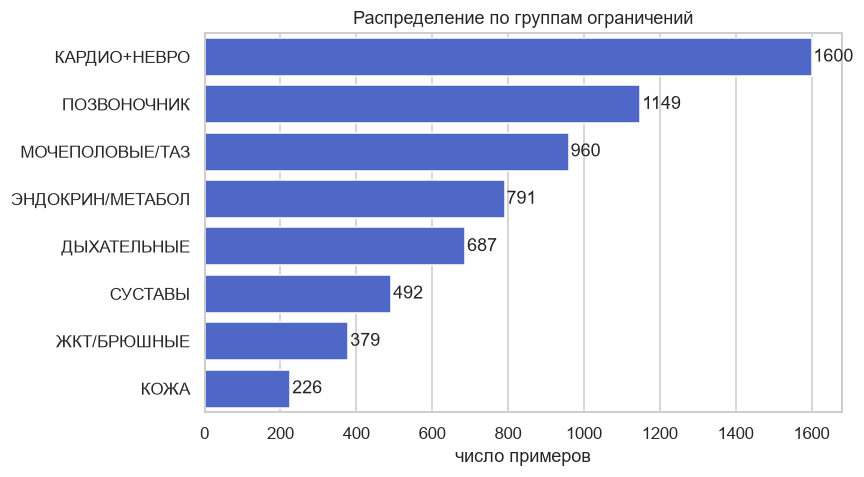

дисбаланс (max/min): 7.1x  (КАРДИО+НЕВРО 1600 vs КОЖА 226)
доля most-frequent class: 0.255


In [3]:
work = df[~df["dropped"]]
counts = work["group"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#3b5bdb")
ax.set_xlabel("число примеров")
ax.set_ylabel("")
ax.set_title("Распределение по группам ограничений")
for i, v in enumerate(counts.values):
    ax.text(v + 5, i, str(v), va="center")
fig.tight_layout()
fig.savefig(REPORTS / "group_distribution.png")
plt.show()

ratio = counts.max() / counts.min()
print(f"дисбаланс (max/min): {ratio:.1f}x  ({counts.idxmax()} {counts.max()} vs {counts.idxmin()} {counts.min()})")
print(f"доля most-frequent class: {counts.max() / counts.sum():.3f}")

In [4]:
pivot = (
    work.groupby(["group", "split"]).size().unstack(fill_value=0)
    .reindex(columns=["train", "dev", "test"])
    .loc[counts.index]
)
print("баланс групп по сплитам (доли):")
pivot.div(pivot.sum(axis=0), axis=1).round(3)

баланс групп по сплитам (доли):


split,train,dev,test
group,,,
КАРДИО+НЕВРО,0.247,0.290,0.265
ПОЗВОНОЧНИК,0.188,0.164,0.170
МОЧЕПОЛОВЫЕ/ТАЗ,0.157,0.133,0.147
ЭНДОКРИН/МЕТАБОЛ,0.125,0.125,0.130
ДЫХАТЕЛЬНЫЕ,0.108,0.113,0.113
СУСТАВЫ,0.081,0.068,0.075
ЖКТ/БРЮШНЫЕ,0.059,0.061,0.065
КОЖА,0.034,0.045,0.036


## Доминирующие коды внутри групп

Если один код перетягивает группу, модель рискует выучить его, а не группу в целом.

In [5]:
for g in counts.index:
    sub = work[work["group"] == g]["code"].value_counts()
    top = sub.index[0]
    share = sub.iloc[0] / sub.sum()
    print(f"{g:18s} топ-код {top} ({description_of(top)}) — {share:.0%} группы")

КАРДИО+НЕВРО       топ-код I11 (Гипертензивная болезнь сердца) — 22% группы
ПОЗВОНОЧНИК        топ-код M54 (Дорсалгия) — 64% группы
МОЧЕПОЛОВЫЕ/ТАЗ    топ-код N76 (Воспаление влагалища и вульвы) — 12% группы
ЭНДОКРИН/МЕТАБОЛ   топ-код E06 (Тиреоидит) — 28% группы
ДЫХАТЕЛЬНЫЕ        топ-код J06 (ОРВИ верхних дыхательных путей) — 24% группы
СУСТАВЫ            топ-код M13 (Другие артриты) — 24% группы
ЖКТ/БРЮШНЫЕ        топ-код K29 (Гастрит и дуоденит) — 28% группы
КОЖА               топ-код L30 (Другие дерматиты) — 24% группы


## Длины текстов жалоб

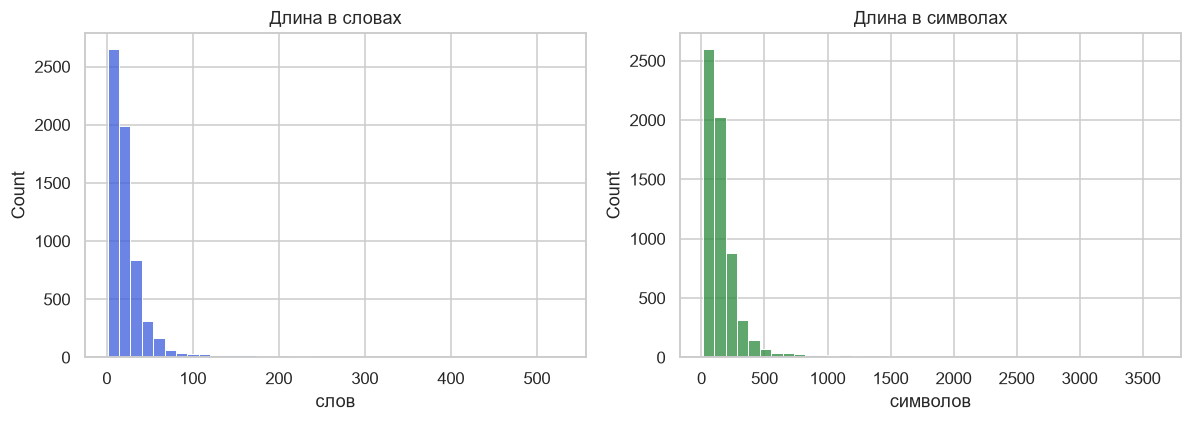

       n_words  n_chars
count   6284.0   6284.0
mean      25.9    177.5
std       35.6    238.5
min        1.0     10.0
25%       10.0     71.0
50%       17.0    119.0
75%       28.0    196.0
max      531.0   3627.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(work["n_words"], bins=40, ax=axes[0], color="#3b5bdb")
axes[0].set_title("Длина в словах")
axes[0].set_xlabel("слов")
sns.histplot(work["n_chars"], bins=40, ax=axes[1], color="#2b8a3e")
axes[1].set_title("Длина в символах")
axes[1].set_xlabel("символов")
fig.tight_layout()
fig.savefig(REPORTS / "text_lengths.png")
plt.show()

print(work[["n_words", "n_chars"]].describe().round(1))

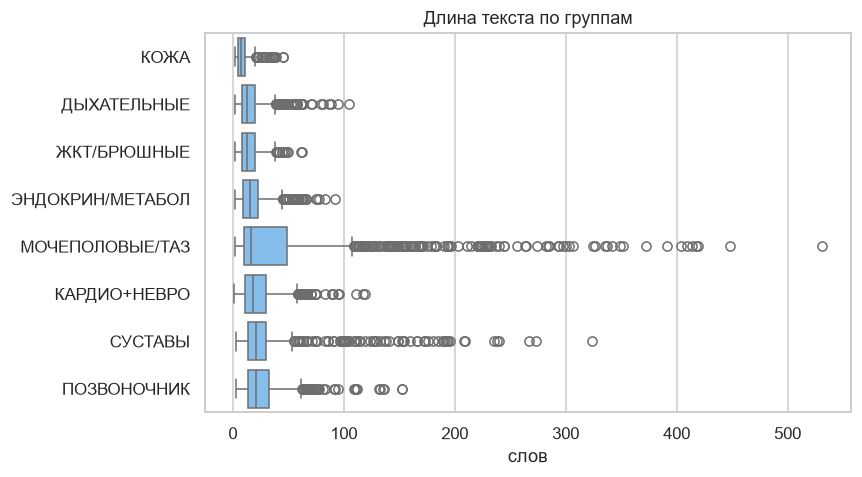

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = work.groupby("group")["n_words"].median().sort_values().index
sns.boxplot(data=work, x="n_words", y="group", order=order, ax=ax, color="#74c0fc")
ax.set_title("Длина текста по группам")
ax.set_xlabel("слов")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(REPORTS / "length_by_group.png")
plt.show()

## Проверка утечек между сплитами

Один и тот же текст не должен попадать в разные сплиты — иначе оценка завышена.

In [8]:
norm = df["text"].apply(normalize)
df_norm = df.assign(norm=norm)

split_sets = {s: set(df_norm[df_norm["split"] == s]["norm"]) for s in ("train", "dev", "test")}
for a, b in (("train", "dev"), ("train", "test"), ("dev", "test")):
    overlap = split_sets[a] & split_sets[b]
    print(f"{a} ∩ {b}: {len(overlap)} пересечений")

dup_in_train = df_norm[df_norm["split"] == "train"]["norm"].duplicated().sum()
print(f"дубликаты внутри train: {dup_in_train}")

train ∩ dev: 0 пересечений
train ∩ test: 0 пересечений
dev ∩ test: 0 пересечений
дубликаты внутри train: 1


## Выводы

- Классы несбалансированы → главная метрика **macro-F1**, baseline LogReg с `class_weight=balanced`.
- Внутри некоторых групп доминирует один код — учитываем при анализе ошибок.
- Тексты короткие → tf-idf и субсловные модели (fastText) уместны.
- Утечек между сплитами нет → оценка честная.